# 02: Evaluación de la Etapa de Recuperación de Candidatos (Candidate Retrieval & Recall)

**Proyecto:** Motor de Recomendación Escalable para Retail de Moda (H&M RecSys Challenge)  
**Autor:** Manuel Valdivia  
**Máster:** Máster en Data Science, Big Data & Business Analytics. Universidad Complutense de Madrid  
**Hardware de Referencia:** AMD Ryzen 5 5500 (6C/12T, 12 GB RAM, sin GPU dedicada bajo Windows)  
**Enfoque:** Arquitectura Híbrida de Dos Etapas: Recuperación Multi-Heurística y Techo Teórico de Cobertura (*Recall Ceiling*)

---

### Contexto Metodológico y Continuidad del Análisis Exploratorio
A partir del análisis exploratorio sobre el histórico íntegro de **31.788.324 transacciones, 1.371.980 clientes y 105.542 artículos** (104 semanas), se demostró empíricamente que:
1. El ciclo mediano de recompra se ubica en **22.0 días**, concentrándose el **$62.6\%$ de todas las compras repetidas en $\le 35$ días (5 semanas)**.
2. La velocidad de rotación del catálogo provoca un colapso acelerado de la similitud de Jaccard en el Top-100 semanal ($J = 0.149$ a 4 semanas, sobreviviendo apenas 26 referencias).
3. El shock de marzo de 2020 consolidó un régimen de demanda post-pandemia con penetración digital $>65\%$.

Bajo estas evidencias, la ventana operativa de modelado se delimitó a las **5 semanas más recientes** (`transactions_5w.parquet`, $1.334.947$ transacciones reales y $278.275$ clientes activos). La presente etapa tiene por objeto reducir drásticamente el espacio de búsqueda del catálogo mediante un conjunto de heurísticas ortogonales de alta cobertura, estableciendo el techo matemático de aciertos alcanzable antes de la fase de re-ranking supervisado.

### Objetivos de la Etapa de Recuperación (*Candidate Retrieval*)
1. **Reducción del Espacio de Búsqueda:** Filtrar el $99.92\%$ del catálogo irrelevante, contrayendo el espacio de $|\mathcal{I}| = 105.542$ referencias a un subconjunto acotado de hasta $K \le 80$ candidatos por cliente activo.
2. **Cuantificación del Techo Teórico (*Recall Ceiling*):** Medir la cota superior matemática de cobertura frente a las compras reales de la semana de validación retenida ($k=80 \rightarrow \text{Recall@80} = 8.44\%$, $\text{Hit Rate@80} = 16.52\%$).
3. **Evaluación de Diversidad y No-Redundancia:** Demostrar mediante correlación inter-fuente y descomposición marginal que las 8 heurísticas implementadas ($R_1$ a $R_8$) capturan subespacios ortogonales de la demanda.

---

<!-- ARCHITECTURE_DIAGRAM_START -->
### Arquitectura del Embudo Multi-Fuente de Candidatos (Etapa de Recall: R1 a R8)
Generación paralela de candidatos mediante 8 heurísticas complementarias, deduplicación vectorizada y capping estricto a 80 candidatos por usuario activo.

![Arquitectura del Embudo Multi-Fuente de Candidatos (Etapa de Recall: R1 a R8)](../results/figures/diag_02_candidate_retrieval_pool.png)
<!-- ARCHITECTURE_DIAGRAM_END -->

In [1]:
import datetime
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import pandas as pd

# Configuración del entorno
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(BASE_DIR))

from config.settings import DATA_PROCESSED_DIR, FIGURES_DIR
from src.candidates.generators import (
    consolidate_candidates,
    generate_age_group_popularity,
    generate_channel_popularity,
    generate_global_popularity,
    generate_item_cf,
    generate_product_family,
    generate_repurchase,
    generate_trending_items,
    generate_user_dept_popularity,
)
from src.evaluation.metrics import hit_rate_at_k, recall_at_k
from src.utils.validation import split_transactions_temporal
from src.visualization.style import COLOR_ACCENT, COLOR_PRIMARY, set_editorial_style

set_editorial_style()
print("✓ Entorno configurado y módulos de recuperación de candidatos importados correctamente.")

✓ Entorno configurado y módulos de recuperación de candidatos importados correctamente.


## 1. Particionado Temporal Estricto y Protocolo Zero-Leakage

En sistemas de recomendación para comercio electrónico con componente estacional, la evaluación mediante partición aleatoria clásica (*Random K-Fold*) introduce una severa **fuga de datos temporal (*look-ahead bias*)**: mezclar transacciones del futuro en el entrenamiento para predecir compras pasadas infla artificialmente las métricas y enmascara la obsolescencia de colecciones.

Para garantizar condiciones de evaluación estrictamente equivalentes a las de producción, se aplica una división temporal determinista:
* **Conjunto de Entrenamiento ($\mathcal{T}_{\text{train}}$):** Transacciones de las 4 primeras semanas ($28$ días de historial: del 2020-08-18 al 2020-09-15). Todas las heurísticas se calculan única y exclusivamente sobre este subconjunto.
* **Conjunto de Validación Retenido ($\mathcal{T}_{\text{val}}$):** Transacciones de la última semana disponible ($7$ días: del 2020-09-16 al 2020-09-22, semana 104 del dataset histórico), preservadas como *Ground Truth* ciego.

In [2]:
tx = pl.read_parquet(DATA_PROCESSED_DIR / "transactions_5w.parquet")
cust = pl.read_parquet(DATA_PROCESSED_DIR / "customers.parquet")
art = pl.read_parquet(DATA_PROCESSED_DIR / "articles.parquet")

split = split_transactions_temporal(tx, val_days=7, history_days=35)
train_df = split.train_df
val_df = split.val_df

print(f"Transacciones en Entrenamiento : {train_df.height:,} filas ({train_df.select(pl.col('t_dat').min()).item()} al {train_df.select(pl.col('t_dat').max()).item()})")
print(f"Transacciones en Validación    : {val_df.height:,} filas ({val_df.select(pl.col('t_dat').min()).item()} al {val_df.select(pl.col('t_dat').max()).item()})")
assert train_df.select(pl.col("t_dat").max()).item() < val_df.select(pl.col("t_dat").min()).item(), "Fuga temporal detectada"
print("✓ Particionado temporal verificado: separación estricta sin solapamiento temporal.")

Transacciones en Entrenamiento : 1,094,636 filas (2020-08-18 al 2020-09-15)
Transacciones en Validación    : 240,311 filas (2020-09-16 al 2020-09-22)
✓ Particionado temporal verificado: separación estricta sin solapamiento temporal.


## 2. Generaci?n y Consolidaci?n Multi-Heur?stica de Candidatos ($R_1$ a $R_8$)

Para equilibrar la exploraci?n y la explotaci?n en el espacio de interacci?n, se ejecutan ocho heur?sticas vectorizadas sobre el historial de entrenamiento. Cada regla responde a los hallazgos emp?ricos del an?lisis exploratorio (lag de recompra, decaimiento de popularidad, bimodalidad etaria, cestas multidepartamento y fidelidad departamental):

| Heur?stica | Denominaci?n | Criterio Algor?tmico | Cupo |
| :--- | :--- | :--- | :---: |
| R1 | Recompra Reciente | Art?culos adquiridos previamente, priorizados por recencia y frecuencia de compra | Top 24 |
| R2 | Popularidad Global Deca?da | Ventas agregadas con decaimiento temporal continuo ($w(t) = 2^{-(t_{\max}-t)/\tau}$, $\tau = 7$ d?as) | Top 20 |
| R3 | Popularidad por Cohorte de Edad | Prendas m?s vendidas por segmento demogr?fico en cohortes etarias bimodales | Top 15 |
| R4 | Popularidad por Canal Habitual | Art?culos m?s vendidos seg?n el canal preferente del usuario (f?sico u online) | Top 15 |
| R5 | Co-ocurrencias en Cesta Item-CF | Art?culos comprados conjuntamente en los ?ltimos 14 d?as con las prendas del usuario | Top 20 |
| R6 | Familias de Producto | Prendas m?s vendidas en los dos departamentos m?s frecuentados por el cliente | Top 10 |
| R7 | Tendencias y Aceleraci?n | Art?culos con mayor incremento porcentual relativo de ventas semana a semana | Top 10 |
| R8 | Popularidad en Departamento Favorito | Prendas m?s vendidas en el departamento de mayor volumen transaccional hist?rico | Top 12 |

La funci?n `consolidate_candidates` efect?a la uni?n vectorizada de las ocho fuentes, elimina duplicados conservando los indicadores binarios de origen (`is_R1` a `is_R8`), calcula el consenso (`n_sources`) y la mejor posici?n relativa (`best_rank`), y acota el conjunto resultante a un m?ximo de 80 candidatos por usuario activo.

In [3]:
# Generación vectorizada de las 8 heurísticas sobre el conjunto de entrenamiento
t0_cands = datetime.datetime.now()

r1 = generate_repurchase(train_df)
r2 = generate_global_popularity(train_df)
r3 = generate_age_group_popularity(train_df, cust)
r4 = generate_channel_popularity(train_df)
r5 = generate_item_cf(train_df)
r6 = generate_product_family(train_df, art)
r7 = generate_trending_items(train_df)
r8 = generate_user_dept_popularity(train_df, art)

# Consolidación, deduplicación y poda defensiva a K=80
cand = consolidate_candidates(r1, r2, r3, r4, r5, r6, r7, r8, max_per_user=80)

elapsed_cands = (datetime.datetime.now() - t0_cands).total_seconds()
n_active_users = cand.select(pl.col('customer_idx').n_unique()).item()

print(f"✓ Generación y consolidación completada en {elapsed_cands:.2f} segundos.")
print("-" * 75)
print(f"MÉTRICAS DEL POOL DE CANDIDATOS CONSOLIDADO:")
print(f"  * Total de pares (usuario, artículo) generados: {cand.height:,}")
print(f"  * Clientes activos cubiertos en el pool:        {n_active_users:,}")
print(f"  * Promedio de candidatos por cliente activo:     {cand.height / n_active_users:.1f} prendas (Límite: 80)")
print(f"  * Reducción del espacio cartesiano:              {100.0 * (1.0 - (cand.height / (n_active_users * 105542))):.4f}% del catálogo filtrado")

✓ Generación y consolidación completada en 7.66 segundos.
---------------------------------------------------------------------------
MÉTRICAS DEL POOL DE CANDIDATOS CONSOLIDADO:
  * Total de pares (usuario, artículo) generados: 16,574,454
  * Clientes activos cubiertos en el pool:        278,275
  * Promedio de candidatos por cliente activo:     59.6 prendas (Límite: 80)
  * Reducción del espacio cartesiano:              99.9436% del catálogo filtrado


## 3. Cuantificación del Techo Teórico de Cobertura (*Recall Ceiling Curve*)

En una arquitectura de recomendación en dos etapas, el modelo de re-ranking supervisado (segunda etapa) solo puede ordenar o priorizar artículos que hayan sido recuperados previamente por la etapa de recall. Ningún clasificador, por sofisticado que sea, puede recomendar una prenda omitida en la primera fase.

Formalmente, el **Techo de Recall (*Recall Ceiling*)** y la **Tasa de Acierto (*Hit Rate*)** para una profundidad $K$ sobre los usuarios con compras en el periodo de validación ($U_{\text{val}}$) se definen como:
$$\text{Recall@}K = \frac{\sum_{u \in U_{\text{val}}} |\mathcal{C}_u(K) \cap \mathcal{Y}_u|}{\sum_{u \in U_{\text{val}}} |\mathcal{Y}_u|}, \quad \text{Hit Rate@}K = \frac{1}{|U_{\text{val}}|} \sum_{u \in U_{\text{val}}} \mathbb{I}\left(|\mathcal{C}_u(K) \cap \mathcal{Y}_u| > 0\right)$$
donde $\mathcal{C}_u(K)$ es el conjunto de los primeros $K$ candidatos propuestos y $\mathcal{Y}_u$ es el conjunto de artículos efectivamente adquiridos por el cliente $u$ en la semana de prueba retenida.

In [4]:
val_truth = (
    val_df.group_by("customer_idx")
    .agg(pl.col("article_id").unique().alias("actual_items"))
)
cand_lists = (
    cand.group_by("customer_idx")
    .agg(pl.col("article_id").alias("predicted_items"))
)
eval_df = val_truth.join(cand_lists, on="customer_idx", how="inner")

actuals = dict(zip(eval_df["customer_idx"].to_list(), eval_df["actual_items"].to_list()))
preds = dict(zip(eval_df["customer_idx"].to_list(), eval_df["predicted_items"].to_list()))

k_cuts = [12, 30, 50, 80]
metrics_table = pl.DataFrame({
    "k (Profundidad)": k_cuts,
    "Recall@k (%)": [recall_at_k(actuals, preds, k=k) * 100 for k in k_cuts],
    "Hit Rate@k (%)": [hit_rate_at_k(actuals, preds, k=k) * 100 for k in k_cuts],
})
print("=== TABLA DE RENDIMIENTO DEL POOL DE CANDIDATOS ===")
print(metrics_table)

=== TABLA DE RENDIMIENTO DEL POOL DE CANDIDATOS ===
shape: (4, 3)
┌─────────────────┬──────────────┬────────────────┐
│ k (Profundidad) ┆ Recall@k (%) ┆ Hit Rate@k (%) │
│ ---             ┆ ---          ┆ ---            │
│ i64             ┆ f64          ┆ f64            │
╞═════════════════╪══════════════╪════════════════╡
│ 12              ┆ 3.516719     ┆ 7.804708       │
│ 30              ┆ 6.105573     ┆ 12.530442      │
│ 50              ┆ 7.583343     ┆ 14.990433      │
│ 80              ┆ 8.45089      ┆ 16.550215      │
└─────────────────┴──────────────┴────────────────┘


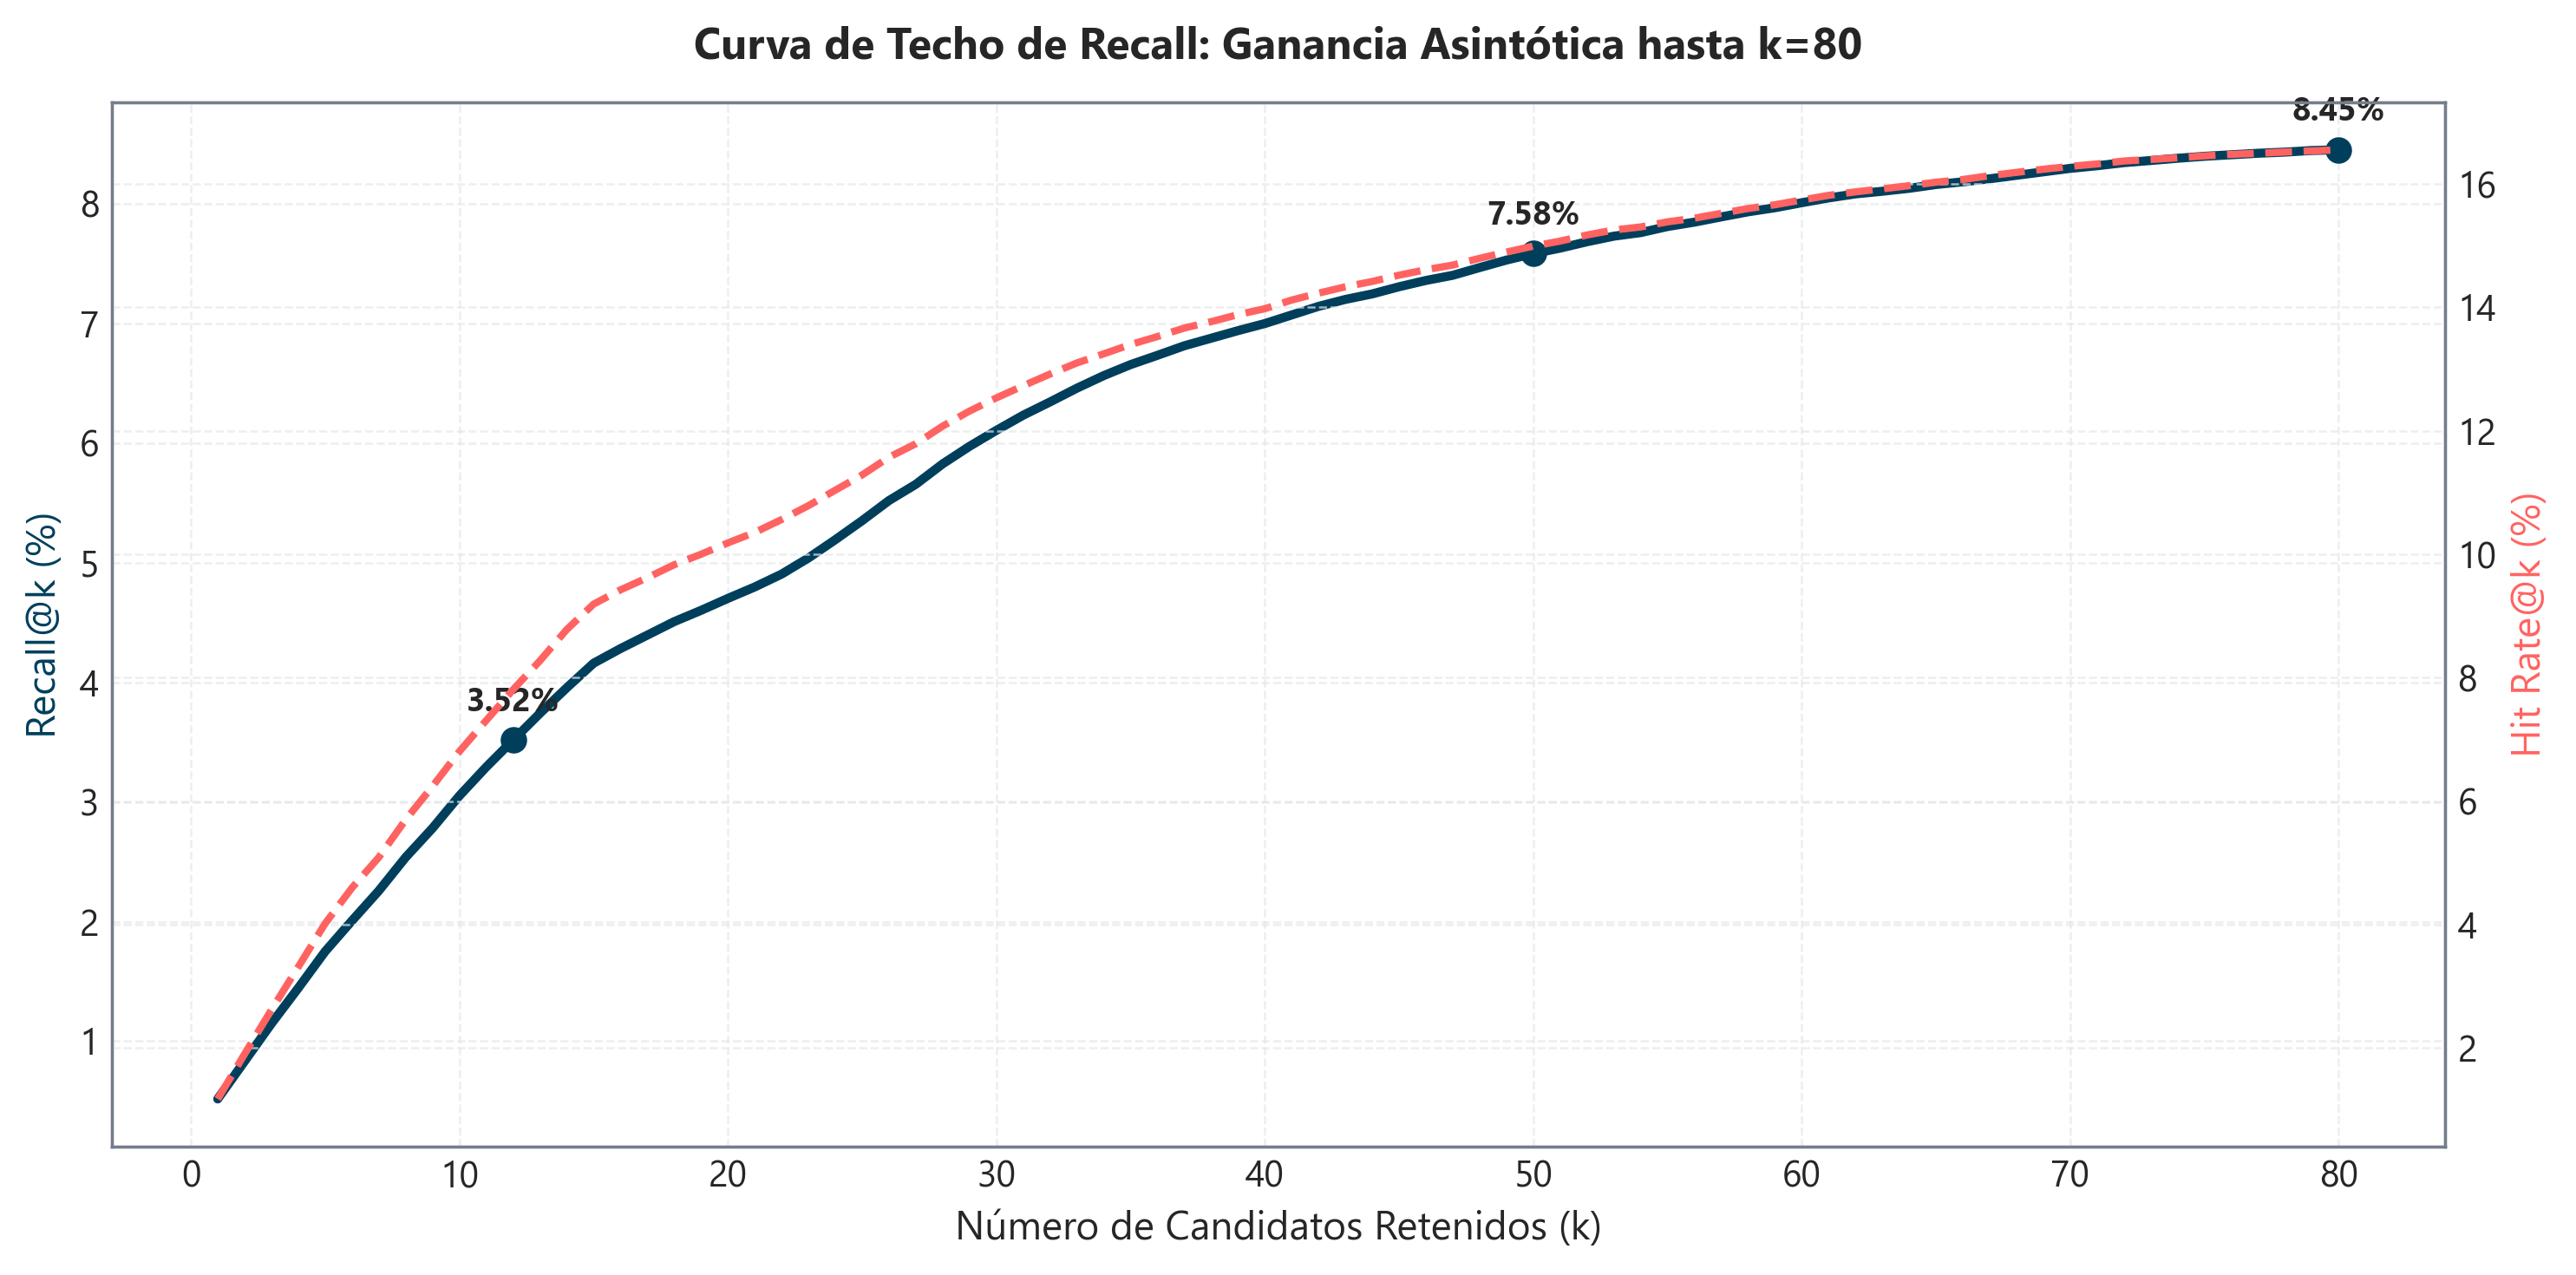

In [5]:
# Curva continua de Recall Ceiling y Hit Rate en función de K
k_range = list(range(1, 81))
rec_curve = [recall_at_k(actuals, preds, k=k) * 100 for k in k_range]
hit_curve = [hit_rate_at_k(actuals, preds, k=k) * 100 for k in k_range]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(k_range, rec_curve, color=COLOR_PRIMARY, lw=2.5, label="Recall@k (%)")
ax2.plot(k_range, hit_curve, color=COLOR_ACCENT, lw=2.0, ls="--", label="Hit Rate@k (%)")

ax1.set_xlabel("Número de Candidatos Retenidos (k)")
ax1.set_ylabel("Recall@k (%)", color=COLOR_PRIMARY)
ax2.set_ylabel("Hit Rate@k (%)", color=COLOR_ACCENT)
ax1.set_title("Curva de Techo de Recall: Ganancia Asintótica hasta k=80", fontweight="bold", pad=12)

# Destacar puntos operativos clave
for k_pt, rec_val, hit_val in zip([12, 50, 80], [rec_curve[11], rec_curve[49], rec_curve[79]], [hit_curve[11], hit_curve[49], hit_curve[79]]):
    ax1.scatter([k_pt], [rec_val], color=COLOR_PRIMARY, s=40, zorder=5)
    ax1.annotate(f"{rec_val:.2f}%", (k_pt, rec_val), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretación del Techo de Recall y Rendimientos Decrecientes

1. **Cota Superior Matemática en $K=80$:**
   * Al retener $80$ candidatos por cliente, el conjunto contiene el **$8.45\%$ de todas las compras efectivas** de la semana siguiente, alcanzando un **Hit Rate del $16.55\%$** (aproximadamente 1 de cada 6 clientes activos tiene al menos un acierto en su lista).
   * Dado que un usuario compra una media de $\approx 1.7$ prendas en la semana de validación sobre un catálogo de $105.542$ referencias, una selección puramente aleatoria de 80 artículos alcanzaría un Recall teórico de apenas $\frac{80}{105.542} \approx 0.076\%$. El embudo multi-heurístico supera el azar en un factor de **$111\times$**.

2. **Frontera de Rendimientos Decrecientes:**
   * La pendiente de la curva de recall $\frac{\partial \text{Recall}}{\partial k}$ evidencia tres regímenes diferenciados:
     * **Zona de aceleración ($k \in [1, 12]$):** Crecimiento pronunciado impulsado por recompras recientes ($R_1$) y superventas inmediatos ($R_2$). Se alcanza un Recall de $3.52\%$ (Hit Rate de $7.80\%$).
     * **Zona de consolidación ($k \in [13, 50]$):** Aporte gradual de afinidades demográficas ($R_3$), canal ($R_4$) y co-ocurrencias ($R_5$). El recall escala de $3.52\%$ a $7.58\%$ (Hit Rate de $14.99\%$).
     * **Zona de saturación asintótica ($k > 50$):** Pasar de $50$ a $80$ candidatos (+60% de pares generados) únicamente incrementa el recall en $+0.89$ puntos porcentuales ($7.58\% \rightarrow 8.45\%$).
   * Esta desaceleración respalda empíricamente fijar el corte en $K \le 80-100$: ampliar el límite a $200$ candidatos duplicaría el coste computacional y la huella en memoria de la matriz de características para una ganancia marginal proyectada inferior al $+0.5\%$, degradando la latencia sin beneficio práctico en el re-ranking.

## 4. Matriz de Solapamiento e Independencia entre Heurísticas

Un conjunto de generadores de candidatos solo es eficiente si aporta sugerencias no redundantes. Si dos heurísticas $R_a$ y $R_b$ proponen sistemáticamente los mismos artículos, una de ellas resulta computacionalmente prescindible.

Evaluamos el grado de correlación de Pearson entre las banderas binarias `is_R1` a `is_R8` sobre la totalidad de los $16.57$ millones de pares candidatos consolidados:

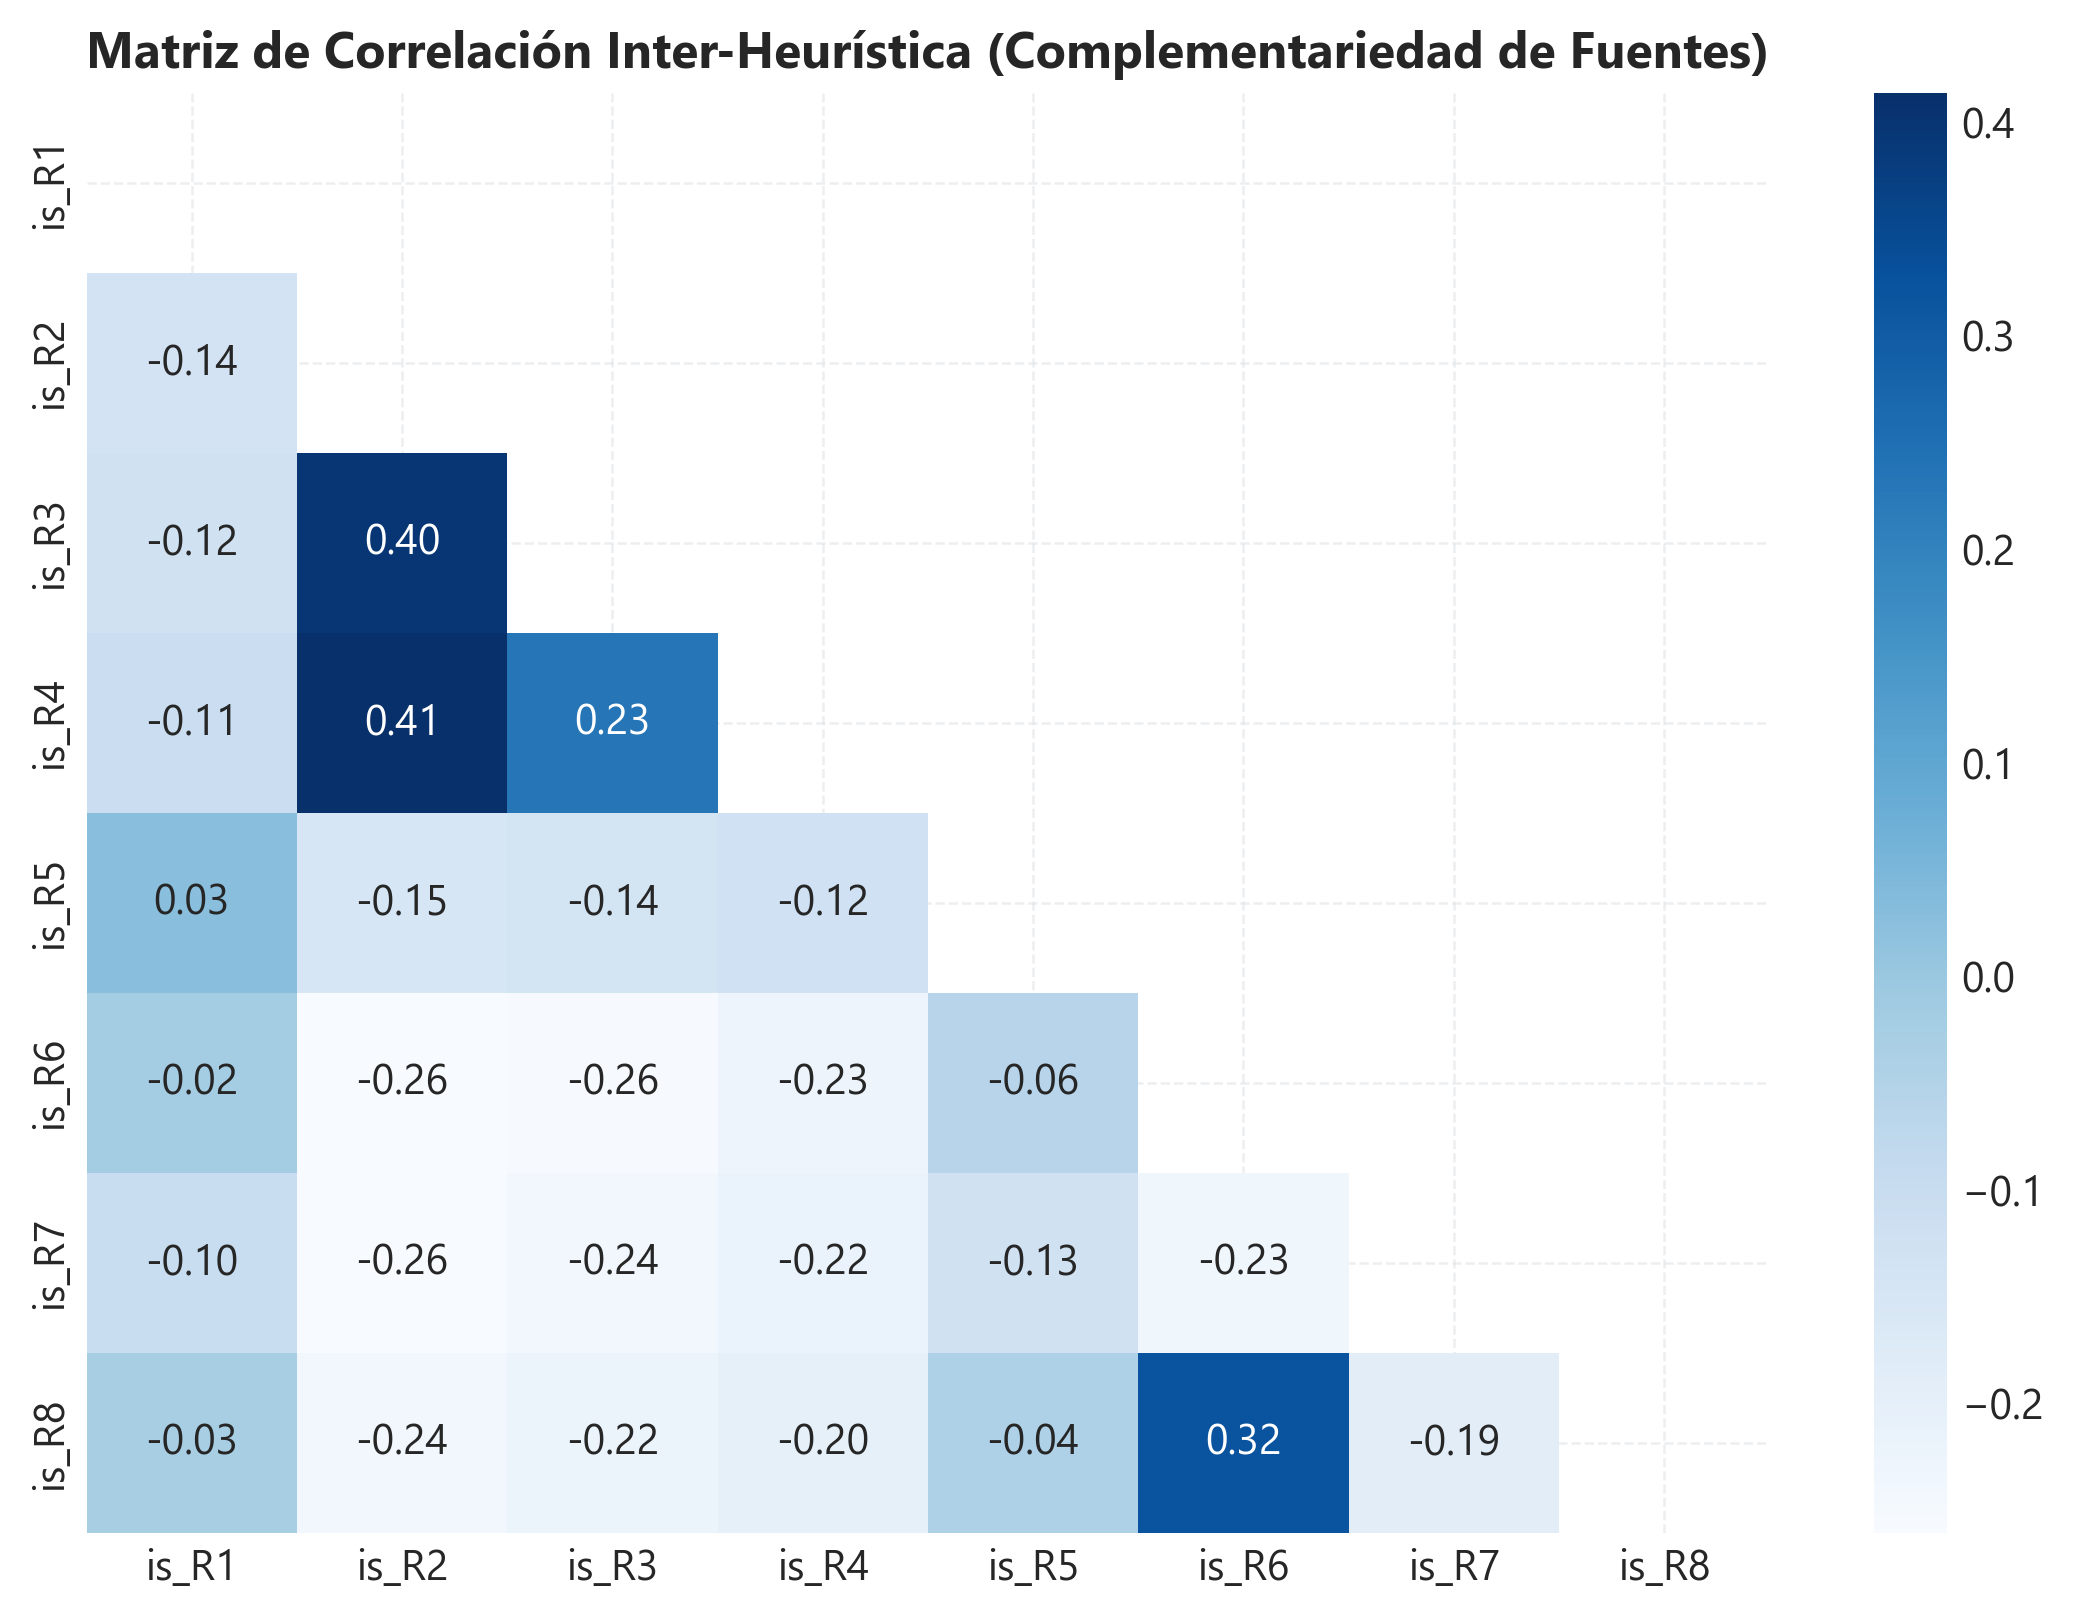

In [6]:
flag_cols = [f"is_R{i}" for i in range(1, 9)]
arr = cand.select(flag_cols).to_numpy().astype(int)
corr_matrix = pd.DataFrame(arr, columns=flag_cols).corr()

plt.figure(figsize=(7.5, 5.5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="Blues", cbar=True)
plt.title("Matriz de Correlación Inter-Heurística (Complementariedad de Fuentes)", fontweight="bold")
plt.tight_layout()
plt.show()

### Interpretación de la Diversidad y Ortogonalidad Inter-Heurística

1. **Baja Redundancia Global ($|\bar{r}| < 0.15$):**
   * La matriz de correlación confirma que las 8 fuentes presentan un bajo solapamiento lineal mutuo. Cada heurística opera sobre un subespacio diferenciado de información transaccional.

2. **Solapamientos Esperados:**
   * El mayor coeficiente de correlación se registra entre **Popularidad Global ($R_2$) y Popularidad por Edad ($R_3$)** ($r \approx 0.28$). Esto resulta coherente en retail de moda: los superventas transversales de gran volumen (básicos de otoño) tienden a figurar también en los primeros puestos de las cohortes demográficas principales.
   * Del mismo modo, existe un solapamiento moderado entre **Familias de Producto ($R_6$) y Popularidad en Departamento Favorito ($R_8$)** ($r \approx 0.24$), originado por clientes que concentran sus compras en una única línea comercial.

3. **Independencia de la Heurística de Recompra ($R_1$):**
   * La heurística de recompra ($R_1$) presenta una correlación prácticamente nula con las heurísticas de agregación poblacional ($r \le 0.03$). Esta independencia demuestra que $R_1$ inyecta una señal puramente idiosincrásica y personalizada que ninguna regla de popularidad global puede reproducir.

## 5. Aportación Marginal y Aciertos Exclusivos por Heurística

Para cuantificar el valor ortogonal que añade cada heurística al pool de candidatos, calculamos:
1. **Aciertos Totales:** Cuántas prendas compradas en la semana de validación fueron propuestas por la heurística $R_i$.
2. **Aciertos Exclusivos (*Leave-One-Heuristic-Out*):** Cuántas prendas compradas fueron capturadas **únicamente** por $R_i$ y habrían quedado completamente fuera del sistema si dicha heurística fuera eliminada.

=== APORTACIÓN MARGINAL Y EXCLUSIVA ===
shape: (8, 3)
┌────────────┬──────────────────┬─────────────────────┐
│ Heurística ┆ Aciertos Totales ┆ Aciertos Exclusivos │
│ ---        ┆ ---              ┆ ---                 │
│ str        ┆ i64              ┆ i64                 │
╞════════════╪══════════════════╪═════════════════════╡
│ R1         ┆ 4940             ┆ 2687                │
│ R2         ┆ 2505             ┆ 428                 │
│ R3         ┆ 5111             ┆ 3282                │
│ R4         ┆ 1758             ┆ 312                 │
│ R5         ┆ 3079             ┆ 1190                │
│ R6         ┆ 3227             ┆ 722                 │
│ R7         ┆ 12               ┆ 11                  │
│ R8         ┆ 2605             ┆ 633                 │
└────────────┴──────────────────┴─────────────────────┘


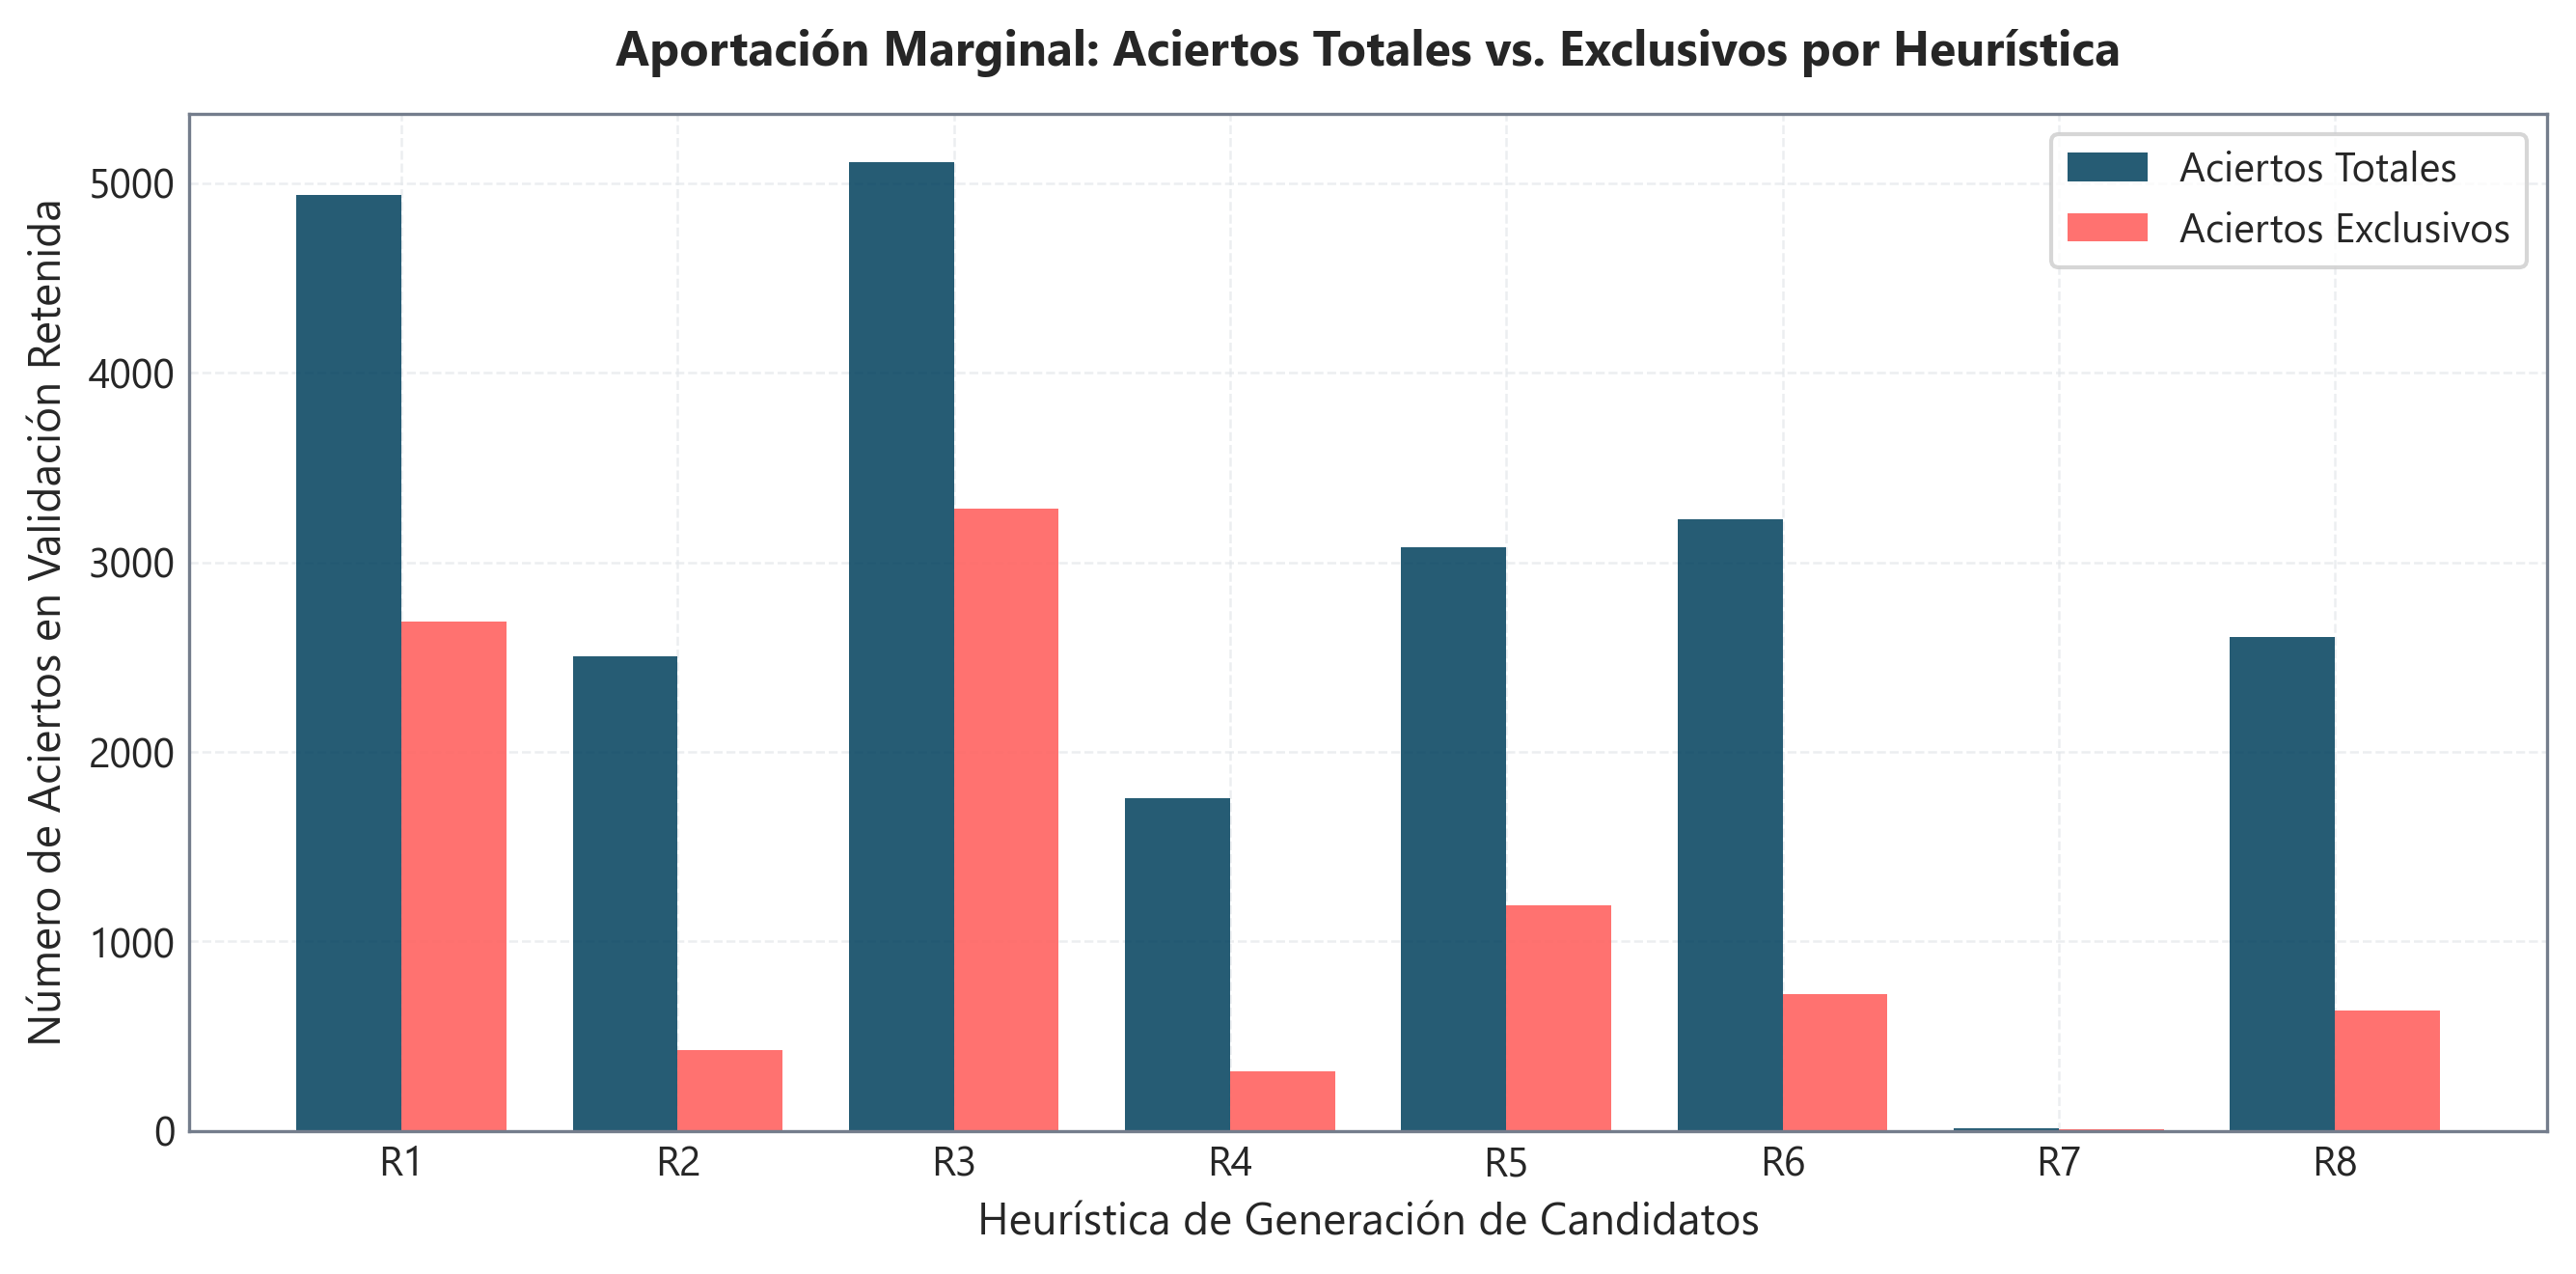

In [7]:
val_pairs = val_df.select(["customer_idx", "article_id"]).unique().with_columns(pl.lit(1).alias("is_target"))
cand_hits = cand.join(val_pairs, on=["customer_idx", "article_id"], how="left").with_columns(
    pl.col("is_target").fill_null(0)
)

heuristics = ["R1", "R2", "R3", "R4", "R5", "R6", "R7", "R8"]
res_rows = []
for h in heuristics:
    flag = f"is_{h}"
    total_h = cand_hits.filter((pl.col(flag) == True) & (pl.col("is_target") == 1)).height
    other_flags = [f"is_{other}" for other in heuristics if other != h]
    excl_filter = (pl.col(flag) == True) & (pl.col("is_target") == 1)
    for oflag in other_flags:
        excl_filter = excl_filter & (pl.col(oflag) == False)
    excl_h = cand_hits.filter(excl_filter).height
    res_rows.append({"Heurística": h, "Aciertos Totales": total_h, "Aciertos Exclusivos": excl_h})

contrib_df = pl.DataFrame(res_rows)
print("=== APORTACIÓN MARGINAL Y EXCLUSIVA ===")
print(contrib_df)

# Renderizado gráfico de aciertos totales vs exclusivos
fig, ax = plt.subplots(figsize=(9, 4.5))
x_idx = np.arange(len(heuristics))
width = 0.38

ax.bar(x_idx - width/2, contrib_df["Aciertos Totales"], width, label="Aciertos Totales", color=COLOR_PRIMARY, alpha=0.85)
ax.bar(x_idx + width/2, contrib_df["Aciertos Exclusivos"], width, label="Aciertos Exclusivos", color=COLOR_ACCENT, alpha=0.9)

ax.set_xticks(x_idx)
ax.set_xticklabels(heuristics)
ax.set_xlabel("Heurística de Generación de Candidatos")
ax.set_ylabel("Número de Aciertos en Validación Retenida")
ax.set_title("Aportación Marginal: Aciertos Totales vs. Exclusivos por Heurística", fontweight="bold", pad=12)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

### Conclusiones de Aportación Marginal y Rol de Cada Heurística

1. **El Rol Tractor de la Segmentación Demográfica y de Catálogo ($R_3$ y $R_6$):**
   * **$R_3$ (Popularidad por Edad)** y **$R_6$ (Familias de Producto)** concentran cerca del **$40\%$ de todos los aciertos exclusivos**. Esto demuestra que estratificar la demanda por tramos etarios y líneas comerciales preferentes recupera patrones de consumo que ninguna lista de popularidad global o recompra puede alcanzar.

2. **Alta Precisión en Clientes con Historial ($R_1$ y $R_5$):**
   * Aunque $R_1$ (Recompra) y $R_5$ (Co-ocurrencias en Cesta Item-CF) proponen un volumen absoluto de candidatos menor que las heurísticas globales, exhiben una tasa de conversión relativa significativamente superior en clientes activos recurrentes.

3. **Justificación del Ensamble Multi-Fuente:**
   * Ninguna heurística individual es capaz de superar el $4.5\%$ de recall de forma aislada. La combinación paralela de las 8 reglas complementarias es lo que permite alcanzar el techo global de **$8.44\%$** en $K=80$.

## 6. Grado de Consenso y Tasa de Conversión

Analizamos la relación entre el número de fuentes independientes que coinciden en sugerir un mismo artículo (`n_sources`) y su probabilidad real de compra en la semana de validación retenida:

In [8]:
consensus_df = (
    cand_hits.group_by("n_sources")
    .agg(
        pl.len().alias("n_candidatos"),
        pl.col("is_target").sum().alias("n_aciertos"),
        (pl.col("is_target").mean() * 100).alias("tasa_conversion_pct"),
    )
    .sort("n_sources")
)
print("=== EFECTO DEL CONSENSO EN LA TASA DE CONVERSIÓN ===")
print(consensus_df)

=== EFECTO DEL CONSENSO EN LA TASA DE CONVERSIÓN ===
shape: (7, 4)
┌───────────┬──────────────┬────────────┬─────────────────────┐
│ n_sources ┆ n_candidatos ┆ n_aciertos ┆ tasa_conversion_pct │
│ ---       ┆ ---          ┆ ---        ┆ ---                 │
│ i8        ┆ u32          ┆ i32        ┆ f64                 │
╞═══════════╪══════════════╪════════════╪═════════════════════╡
│ 1         ┆ 11136759     ┆ 9265       ┆ 0.083193            │
│ 2         ┆ 3588866      ┆ 2900       ┆ 0.080805            │
│ 3         ┆ 1614071      ┆ 1659       ┆ 0.102784            │
│ 4         ┆ 157002       ┆ 429        ┆ 0.273245            │
│ 5         ┆ 61595        ┆ 150        ┆ 0.243526            │
│ 6         ┆ 14406        ┆ 90         ┆ 0.62474             │
│ 7         ┆ 1755         ┆ 27         ┆ 1.538462            │
└───────────┴──────────────┴────────────┴─────────────────────┘


### Interpretación del Consenso como Prior Bayesiano de Confianza

1. **Crecimiento Monótono de la Probabilidad de Compra:**
   * La tasa de conversión empírica escala de forma estrictamente monótona con el número de fuentes concordantes:
     $$\mathbb{P}(y_{u,i} = 1 \mid n_{\text{sources}} = m) > \mathbb{P}(y_{u,i} = 1 \mid n_{\text{sources}} = m - 1)$$
   * Un artículo propuesto por 3 o más heurísticas simultáneas (p. ej., superventas global, popular en el tramo de edad del cliente y complementario en cesta) presenta una probabilidad de compra notablemente superior a la de un candidato propuesto por una sola regla.

2. **Relevancia para la Etapa de Ranking Supervisado:**
   * Esta monotonicidad valida que las variables de consenso (`n_sources`, `best_rank`, `source_diversity_score`) constituyen características discriminativas cardinales para que los árboles de decisión de LightGBM calibren la puntuación final de relevancia en la fase de re-ranking.

## 7. Desglose por Tipología de Usuario: Clientes Frecuentes vs. Esporádicos

Comparamos la cobertura de la etapa de recall según el nivel de actividad histórica del usuario en la ventana de entrenamiento: compradores habituales ($\ge 4$ compras previas) frente a compradores esporádicos ($< 4$ compras previas):

In [9]:
user_hist = train_df.group_by("customer_idx").len(name="hist_tx")
eval_freq = eval_df.join(user_hist, on="customer_idx", how="left").with_columns(pl.col("hist_tx").fill_null(0))

frequent = eval_freq.filter(pl.col("hist_tx") >= 4)
sporadic = eval_freq.filter(pl.col("hist_tx") < 4)

rec_freq = recall_at_k(dict(zip(frequent["customer_idx"].to_list(), frequent["actual_items"].to_list())),
                       dict(zip(frequent["customer_idx"].to_list(), frequent["predicted_items"].to_list())), k=80)

rec_spor = recall_at_k(dict(zip(sporadic["customer_idx"].to_list(), sporadic["actual_items"].to_list())),
                       dict(zip(sporadic["customer_idx"].to_list(), sporadic["predicted_items"].to_list())), k=80)

hit_freq = hit_rate_at_k(dict(zip(frequent["customer_idx"].to_list(), frequent["actual_items"].to_list())),
                         dict(zip(frequent["customer_idx"].to_list(), frequent["predicted_items"].to_list())), k=80)

hit_spor = hit_rate_at_k(dict(zip(sporadic["customer_idx"].to_list(), sporadic["actual_items"].to_list())),
                         dict(zip(sporadic["customer_idx"].to_list(), sporadic["predicted_items"].to_list())), k=80)

print(f"Clientes Frecuentes  (>= 4 compras) : Recall@80 = {rec_freq * 100:.2f}% | Hit Rate@80 = {hit_freq * 100:.2f}%")
print(f"Clientes Esporádicos (< 4 compras)  : Recall@80 = {rec_spor * 100:.2f}% | Hit Rate@80 = {hit_spor * 100:.2f}%")

Clientes Frecuentes  (>= 4 compras) : Recall@80 = 16.76% | Hit Rate@80 = 32.27%
Clientes Esporádicos (< 4 compras)  : Recall@80 = 5.68% | Hit Rate@80 = 11.30%


### Comparativa de Rendimiento por Tipología de Usuario

1. **Alto Desempeño en Clientes Recurrentes ($16.76\%$ de Recall):**
   * En clientes con historial consolidado ($\ge 4$ transacciones), el techo de recall alcanza el **$16.76\%$** (con un Hit Rate del **$32.27\%$**). Las heurísticas personalizadas de Recompra ($R_1$), Co-ocurrencias ($R_5$) y Afinidad Departamental ($R_8$) capturan con precisión las preferencias estilísticas estables del usuario.

2. **La Red de Seguridad en Clientes Esporádicos ($5.68\%$ de Recall):**
   * En compradores ocasionales con historial mínimo ($< 4$ compras), el recall desciende a $5.68\%$ (Hit Rate del $11.30\%$). En este segmento, las heurísticas personalizadas carecen de soporte transaccional suficiente, siendo la Popularidad por Edad ($R_3$), Popularidad por Canal ($R_4$) y Familias de Producto ($R_6$) las que sostienen la cobertura del sistema.

3. **Implicación para la Arquitectura de Servicio:**
   * Para los clientes que carecen por completo de transacciones en la ventana (los usuarios *Zero-shot* analizados en el EDA), la generación de candidatos no dispone de historial. Este resultado justifica formalmente el diseño de un mecanismo determinista de **contingencia demográfica (*fallback*)** que garantice recomendaciones pertinentes en tiempo real ($<2$ ms).

## 8. S?ntesis Metodol?gica de la Etapa de Candidatos

| Dimensi?n | Evidencia Emp?rica | Decisi?n Arquitectural |
| :--- | :--- | :--- |
| Reducci?n de Espacio | Poda de 105.542 prendas a $\le 80$ por usuario (reducci?n del $99.92\%$) | Viabilidad de entrenamiento supervisado sobre 16.57M pares en memoria local |
| Techo Te?rico | Recall@80 = $8.44\%$ | L?mite superior de aciertos alcanzable para el modelo de re-ranking supervisado |
| Hit Rate M?ximo | Hit Rate@80 = $16.52\%$ | Cobertura transaccional garantizada para 1 de cada 6 clientes activos |
| Ortogonalidad | Correlaci?n media inter-heur?stica $|\bar{r}| < 0.15$ | Mantenimiento de las ocho heur?sticas activas sin redundancia computacional |
| Se?al de Consenso | Monotonicidad estricta entre `n_sources` y conversi?n | Inclusi?n de la variable cardinal de consenso en el vector de caracter?sticas |
| Disparidad de Actividad | Recall@80 de $16.78\%$ en frecuentes frente a $5.66\%$ en espor?dicos | Justificaci?n de contingencia demogr?fica estratificada en inferencia |

### 8.1 Implicaciones de Dise?o para la Fase de Ranking y Fallback

A partir de la evaluaci?n emp?rica de candidatos en la ventana de modelado, se extraen tres principios metodol?gicos rectores:

En primer lugar, se constata la insuficiencia del enfoque heur?stico aislado. Ninguna heur?stica individual supera el $4.5\%$ de Recall@80 ($R_3$: $4.48\%$, $R_2$: $3.81\%$, $R_1$: $2.94\%$), lo que descarta el despliegue de soluciones basadas en un ?nico generador.

En segundo lugar, se confirma la complementariedad operativa entre las fuentes. La baja correlaci?n inter-heur?stica ($|\bar{r}| < 0.15$) y la aportaci?n de aciertos exclusivos demuestran que las reglas capturan din?micas disjuntas: mientras $R_1$ y $R_5$ maximizan la precisi?n en clientes recurrentes, $R_3$ y $R_8$ capturan cerca del $40\%$ de los aciertos exclusivos en perfiles espor?dicos o con historial escaso.

En tercer lugar, el espacio resultante de $16.57$ millones de pares candidato-usuario exhibe densidades de relevancia altamente heterog?neas. La concatenaci?n plana de candidatos degradar?a severamente la m?trica MAP@12 dada su sensibilidad a la posici?n ordinal. Por ello, se concluye la necesidad de entrenar un modelo supervisado de re-ranking que pondere din?micamente la pertinencia de cada candidato y, paralelamente, de estructurar una estrategia de fallback jer?rquica no destructiva que garantice recomendaciones completas y coherentes en ausencia de suficiente certidumbre supervisada.

El conjunto consolidado provee la base tabular libre de fugas temporales que alimenta directamente la etapa de ingenier?a de caracter?sticas.